# 🥑 Proyecto Machine Learning — Clasificación de Enfermedades en Frutos de Aguacate
## Entregable 1: Entendimiento del Negocio y de los Datos
## Entregable 2: Preparación de los Datos

**Estudiante:**
**Metodología:** CRISP-DM  
**Dataset:** Imágenes de frutos de aguacate variedad Fuerte — 3,983 imágenes  
**Clases:** Sano (Healthy), Roña (Scab), Antracnosis (Anthracnose)  
**Referencia científica:** Campos-Ferreira & González-Camacho (2021). *Clasificador de Red Neuronal Convolucional para Identificar Enfermedades del Fruto de Aguacate.* Agrociencia, 55(8), 695-709.

---

## 📦 0. Instalación de Librerías y Configuración del Entorno

In [2]:
# Instalación de librerías necesarias
!pip install -q kaggle pandas numpy matplotlib seaborn scikit-learn Pillow tensorflow opencv-python-headless imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo de gráficas
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
PALETTE = ['#2ecc71', '#e74c3c', '#3498db']  # Verde=Sano, Rojo=Antracnosis, Azul=Roña

print('Librerías instaladas y configuradas correctamente.')

Librerías instaladas y configuradas correctamente.


## 📂 1. Carga del Dataset

> **Instrucción:** Sube el archivo `Avocado_labels_1.csv` a tu Google Drive o usa el botón de carga de Colab. El dataset contiene las etiquetas de 3,983 imágenes de aguacate con las clases: Healthy, Scab y Anthracnose.

In [3]:
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

# OPCIÓN B — Si el archivo ya está en Drive (descomenta las líneas siguientes)

CSV_PATH = '/content/drive/MyDrive/MachineLearning/AnalisisDatos/Proyecto/Avocado labels 1.csv'

df = pd.read_csv(CSV_PATH)
print(f'\n✅ Dataset cargado correctamente: {df.shape[0]} filas, {df.shape[1]} columnas')
df


✅ Dataset cargado correctamente: 3983 filas, 5 columnas


,Identification,Condition,Healthy,Scab,Anthracnose
0,Avocado 0001,Scab,0,1,0
1,Avocado 0002,Scab,0,1,0
2,Avocado 0003,Healthy,1,0,0
3,Avocado 0004,Scab,0,1,0
4,Avocado 0005,Anthracnose,0,0,1
...,...,...,...,...,...
3978,Avocado 3979,Healthy,1,0,0
3979,Avocado 3980,Scab,0,1,0
3980,Avocado 3981,Healthy,1,0,0
3981,Avocado 3982,Scab,0,1,0


---
# 🏢 ENTREGABLE 1 — Entendimiento del Negocio y de los Datos
---

## 1️⃣ Entrevistas y Análisis Exploratorio

### 1.1 Contexto del Problema (Análisis Exploratorio del Dominio)

México es el **principal productor de aguacate** (*Persea americana* Mill.) a nivel mundial, con una producción anual superior a 2,393,000 toneladas métricas. El cultivo es afectado principalmente por dos enfermedades fúngicas que deterioran la calidad del fruto en postcosecha:

| Enfermedad | Agente causal | Pérdida potencial |
|---|---|---|
| **Antracnosis** | *Colletotrichum* spp. | Hasta 100% en almacenamiento |
| **Roña / Sarna** | *Sphaceloma perseae* Jenkins | Hasta 71% en precosecha |

La variedad **Fuerte**, resultado de la hibridación de las razas Mexicana y Guatemalteca, es la primera variedad comercial de excelencia mundial y se cultiva principalmente en Morelos, Puebla y Oaxaca. A diferencia de la variedad Hass, mantiene un color **verde constante** durante todo su desarrollo, lo cual facilita la identificación visual de enfermedades mediante análisis de imagen.

La inspección manual por técnicos expertos es costosa e impráctica a escala comercial. Los modelos de **aprendizaje profundo (CNN)** ofrecen una alternativa no invasiva, escalable y de bajo costo para automatizar este proceso.

### 1.2 Fuente de Datos

El dataset fue generado como parte de la tesis de licenciatura en Ingeniería Agronómica con especialidad en Parasitología Agrícola (Universidad Autónoma Chapingo). Las imágenes fueron recolectadas en campo en los municipios de **Ocuituco** y **Tetela del Volcán**, Morelos, México, usando una cámara Nikon D3400 en una caja de estudio controlada (fondo blanco, 450 lm de iluminación).

In [5]:
# ─── Análisis Exploratorio Inicial del CSV ───
print('=' * 60)
print('ANÁLISIS EXPLORATORIO — DATASET DE ETIQUETAS')
print('=' * 60)

print('\n📌 Primeras filas:')
display(df.head())

print('\n📌 Tipos de datos:')
print(df.dtypes)

print('\n📌 Dimensiones del dataset:')
print(f'  Filas: {df.shape[0]} | Columnas: {df.shape[1]}')

print('\n📌 Estadísticas descriptivas:')
display(df.describe())

# Mapeo de clases en español
df['Clase_ES'] = df['Condition'].map({'Healthy': 'Sano', 'Scab': 'Roña', 'Anthracnose': 'Antracnosis'})

print('\n📌 Distribución de clases:')
conteo = df['Condition'].value_counts()
for clase, n in conteo.items():
    print(f'  {clase:15s}: {n:5d} imágenes  ({n/len(df)*100:.1f}%)')

ANÁLISIS EXPLORATORIO — DATASET DE ETIQUETAS

📌 Primeras filas:


,Identification,Condition,Healthy,Scab,Anthracnose
0,Avocado 0001,Scab,0,1,0
1,Avocado 0002,Scab,0,1,0
2,Avocado 0003,Healthy,1,0,0
3,Avocado 0004,Scab,0,1,0
4,Avocado 0005,Anthracnose,0,0,1



📌 Tipos de datos:
Identification    object
Condition         object
Healthy            int64
Scab               int64
Anthracnose        int64
dtype: object

📌 Dimensiones del dataset:
  Filas: 3983 | Columnas: 5

📌 Estadísticas descriptivas:


,Healthy,Scab,Anthracnose
count,3983.000000,3983.000000,3983.000000
mean,0.442882,0.300527,0.256591
std,0.496789,0.458545,0.436806
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000



📌 Distribución de clases:
  Healthy        :  1764 imágenes  (44.3%)
  Scab           :  1197 imágenes  (30.1%)
  Anthracnose    :  1022 imágenes  (25.7%)


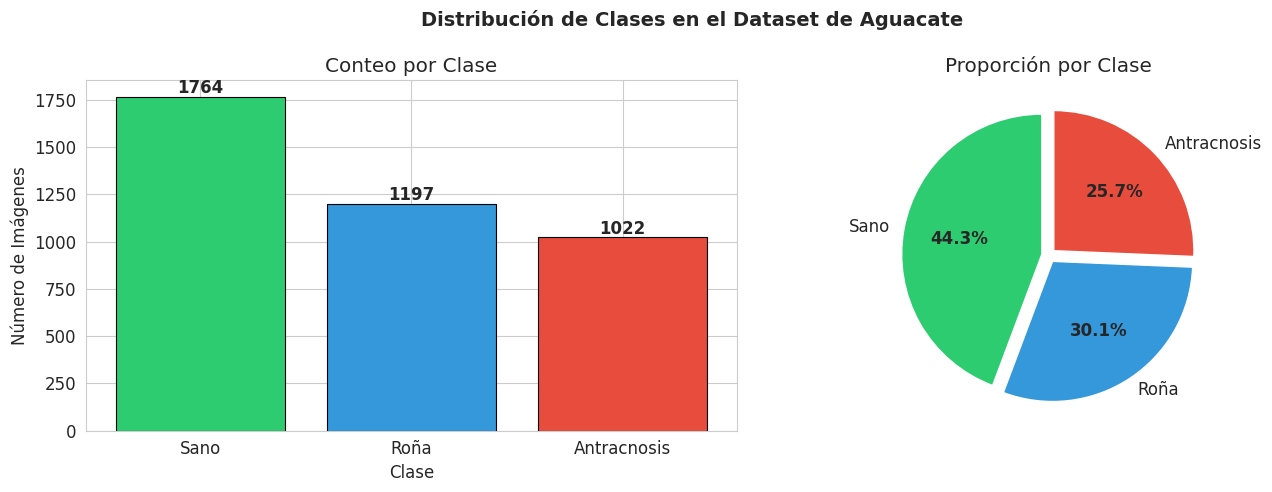

✅ Gráfica guardada: distribucion_clases.png


In [6]:
# ─── Gráfica 1: Distribución de Clases ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Clases en el Dataset de Aguacate', fontsize=14, fontweight='bold')

colores = {'Sano': '#2ecc71', 'Roña': '#3498db', 'Antracnosis': '#e74c3c'}
conteo_es = df['Clase_ES'].value_counts()

# Barras
bars = axes[0].bar(conteo_es.index, conteo_es.values,
                   color=[colores[c] for c in conteo_es.index], edgecolor='black', linewidth=0.8)
axes[0].set_title('Conteo por Clase')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Número de Imágenes')
for bar, val in zip(bars, conteo_es.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')

# Pastel
wedges, texts, autotexts = axes[1].pie(
    conteo_es.values,
    labels=conteo_es.index,
    colors=[colores[c] for c in conteo_es.index],
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05]*3
)
axes[1].set_title('Proporción por Clase')
for at in autotexts:
    at.set_fontweight('bold')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada: distribucion_clases.png')

## 2️⃣ Descripción del Problema e Hipótesis

### 2.1 Planteamiento del Problema

El aguacate variedad Fuerte es susceptible a las enfermedades de **roña** (*Sphaceloma perseae*) y **antracnosis** (*Colletotrichum* spp.) durante la etapa de postcosecha. La identificación manual de estas enfermedades depende de inspectores expertos, proceso que resulta **costoso, subjetivo y no escalable** para volúmenes industriales de producción.

**Pregunta de investigación:**  
> ¿Es posible desarrollar un modelo de clasificación basado en aprendizaje profundo (CNN) que identifique con precisión aceptable (≥ 80%) si un fruto de aguacate variedad Fuerte es sano, presenta roña o presenta antracnosis, a partir de imágenes digitales?

### 2.2 Hipótesis

- **H₁ (Principal):** Un modelo CNN entrenado con imágenes de aguacate variedad Fuerte puede clasificar correctamente las tres condiciones del fruto (sano, roña, antracnosis) con una precisión global ≥ 80%.
- **H₂:** Las técnicas de aumento de datos (*data augmentation*) incrementan la capacidad de generalización del modelo al aumentar la diversidad del conjunto de entrenamiento.
- **H₃:** Existe desbalance entre clases que afectará el desempeño en la clase minoritaria (antracnosis), requiriendo estrategias de compensación.

In [22]:
# ─── Verificación de la Hipótesis 3: Desbalance de Clases ───
conteo_es = df['Clase_ES'].value_counts()
clase_max = conteo_es.max()
clase_min = conteo_es.min()
ratio_desbalance = clase_max / clase_min

print('=' * 50)
print('ANÁLISIS DE DESBALANCE DE CLASES')
print('=' * 50)
print(f'  Clase mayoritaria: {conteo_es.idxmax()} — {clase_max} imágenes')
print(f'  Clase minoritaria: {conteo_es.idxmin()} — {clase_min} imágenes')
print(f'  Ratio de desbalance: {ratio_desbalance:.2f}:1')

if ratio_desbalance > 1.5:
    print('\n⚠️  DESBALANCE DETECTADO. Se requerirán estrategias de compensación.')
    print('     Opciones: oversampling (SMOTE), class_weight, data augmentation.')
else:
    print('\n✅ Dataset relativamente balanceado.')

ANÁLISIS DE DESBALANCE DE CLASES
  Clase mayoritaria: Sano — 1764 imágenes
  Clase minoritaria: Antracnosis — 1022 imágenes
  Ratio de desbalance: 1.73:1

⚠️  DESBALANCE DETECTADO. Se requerirán estrategias de compensación.
     Opciones: oversampling (SMOTE), class_weight, data augmentation.


## 3️⃣ Métricas para Medir el Éxito del Proyecto

| Métrica | Descripción | Valor de Aceptación |
|---|---|---|
| **Precisión Global (PG / Accuracy)** | Proporción de imágenes correctamente clasificadas sobre el total | ≥ 80% |
| **Precisión por Clase (P)** | VP / (VP + FP) — De las predicciones positivas, cuántas son correctas | ≥ 75% por clase |
| **Exhaustividad / Recall (E)** | VP / (VP + FN) — De los casos reales positivos, cuántos detectó el modelo | ≥ 70% por clase |
| **F1-Score** | Media armónica de Precisión y Recall — Métrica conservadora ante desbalance | ≥ 0.70 por clase |
| **Pérdida (Loss)** | Función de costo durante entrenamiento (binary_crossentropy) | Tendencia decreciente y convergente |

> **Justificación:** La precisión global ≥ 80% es el umbral mínimo aceptable basado en Campos-Ferreira & González-Camacho (2021), quienes lograron 80% en validación y 87% en prueba. El F1-Score es especialmente relevante dado el desbalance de clases detectado.

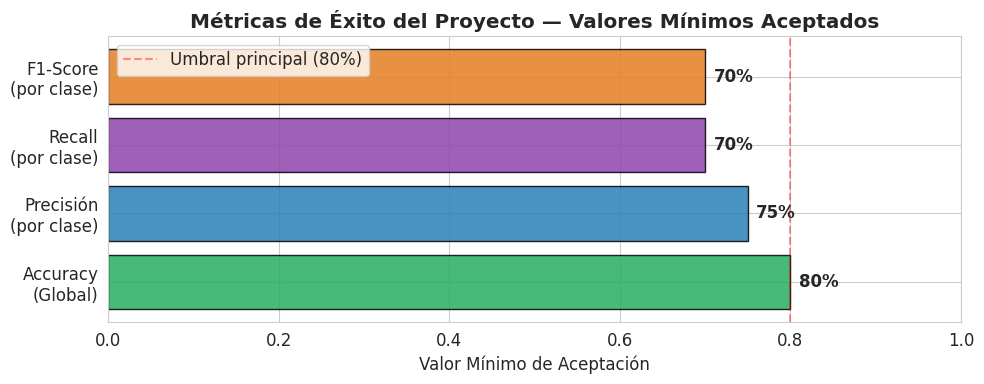

✅ Gráfica guardada: metricas_objetivo.png


In [8]:
# ─── Visualización de Métricas Objetivo ───
fig, ax = plt.subplots(figsize=(10, 4))

metricas = ['Accuracy\n(Global)', 'Precisión\n(por clase)', 'Recall\n(por clase)', 'F1-Score\n(por clase)']
valores_min = [0.80, 0.75, 0.70, 0.70]
colores_met = ['#27ae60', '#2980b9', '#8e44ad', '#e67e22']

bars = ax.barh(metricas, valores_min, color=colores_met, alpha=0.85, edgecolor='black')
ax.set_xlim(0, 1.0)
ax.set_xlabel('Valor Mínimo de Aceptación')
ax.set_title('Métricas de Éxito del Proyecto — Valores Mínimos Aceptados', fontweight='bold')

for bar, val in zip(bars, valores_min):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val*100:.0f}%', va='center', fontweight='bold', fontsize=12)

ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.4, label='Umbral principal (80%)')
ax.legend()
plt.tight_layout()
plt.savefig('metricas_objetivo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada: metricas_objetivo.png')

## 4️⃣ Reporte de Calidad de Datos

### 4.1 Revisión Inicial del Dataset de Etiquetas

In [9]:
# ─── Calidad de Datos — Revisión Completa ───
print('=' * 60)
print('REPORTE DE CALIDAD DE DATOS')
print('=' * 60)

# Valores nulos
print('\n📌 Valores nulos por columna:')
nulos = df.isnull().sum()
print(nulos)
print(f'  Total de celdas nulas: {nulos.sum()}')

# Duplicados
print(f'\n📌 Registros duplicados: {df.duplicated().sum()}')

# Valores únicos
print('\n📌 Valores únicos por columna:')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()} valores únicos')

# Verificación de consistencia entre columnas
print('\n📌 Verificación de consistencia en columnas de codificación one-hot:')
df_num = df[['Healthy', 'Scab', 'Anthracnose']]
suma_cols = df_num.sum(axis=1)
inconsistentes = (suma_cols != 1).sum()
print(f'  Registros donde la suma de Healthy+Scab+Anthracnose ≠ 1: {inconsistentes}')

if inconsistentes == 0:
    print('  ✅ Todas las etiquetas one-hot son consistentes (exactamente una clase por imagen).')
else:
    print('  ⚠️  Se detectaron inconsistencias. Revisar manualmente.')

# Verificación de que Condition coincide con columnas one-hot
mapeo = {'Healthy': [1,0,0], 'Scab': [0,1,0], 'Anthracnose': [0,0,1]}
errores = 0
for _, row in df.iterrows():
    esperado = mapeo.get(row['Condition'], None)
    real = [row['Healthy'], row['Scab'], row['Anthracnose']]
    if esperado and real != esperado:
        errores += 1
print(f'\n📌 Consistencia entre columna Condition y columnas numéricas:')
print(f'  Errores encontrados: {errores}')
if errores == 0:
    print('  ✅ Consistencia perfecta entre etiquetas textuales y numéricas.')

REPORTE DE CALIDAD DE DATOS

📌 Valores nulos por columna:
Identification    0
Condition         0
Healthy           0
Scab              0
Anthracnose       0
Clase_ES          0
dtype: int64
  Total de celdas nulas: 0

📌 Registros duplicados: 0

📌 Valores únicos por columna:
  Identification: 3983 valores únicos
  Condition: 3 valores únicos
  Healthy: 2 valores únicos
  Scab: 2 valores únicos
  Anthracnose: 2 valores únicos
  Clase_ES: 3 valores únicos

📌 Verificación de consistencia en columnas de codificación one-hot:
  Registros donde la suma de Healthy+Scab+Anthracnose ≠ 1: 0
  ✅ Todas las etiquetas one-hot son consistentes (exactamente una clase por imagen).

📌 Consistencia entre columna Condition y columnas numéricas:
  Errores encontrados: 0
  ✅ Consistencia perfecta entre etiquetas textuales y numéricas.


In [10]:
# ─── Análisis de Formato de Nombres de Imagen ───
import re

print('📌 Análisis del formato de identificadores de imagen:')
patron = re.compile(r'^Avocado \d{4}$')
ids_invalidos = df[~df['Identification'].str.match(r'^Avocado \d{4}$')]
print(f'  Total de imágenes: {len(df)}')
print(f'  IDs con formato inválido: {len(ids_invalidos)}')

# Extraer número y verificar secuencia
df['num'] = df['Identification'].str.extract(r'(\d+)').astype(int)
print(f'  Rango numérico: {df["num"].min()} — {df["num"].max()}')
print(f'  Imágenes esperadas (1-3983): 3983')
print(f'  Imágenes en dataset: {len(df)}')

faltantes = set(range(1, 3984)) - set(df['num'].values)
print(f'  Números de imagen faltantes en la secuencia: {len(faltantes)}')
if len(faltantes) == 0:
    print('  ✅ Secuencia completa sin imágenes faltantes.')
else:
    print(f'  ⚠️  Primeros faltantes: {sorted(list(faltantes))[:10]}')

📌 Análisis del formato de identificadores de imagen:
  Total de imágenes: 3983
  IDs con formato inválido: 0
  Rango numérico: 1 — 3983
  Imágenes esperadas (1-3983): 3983
  Imágenes en dataset: 3983
  Números de imagen faltantes en la secuencia: 0
  ✅ Secuencia completa sin imágenes faltantes.


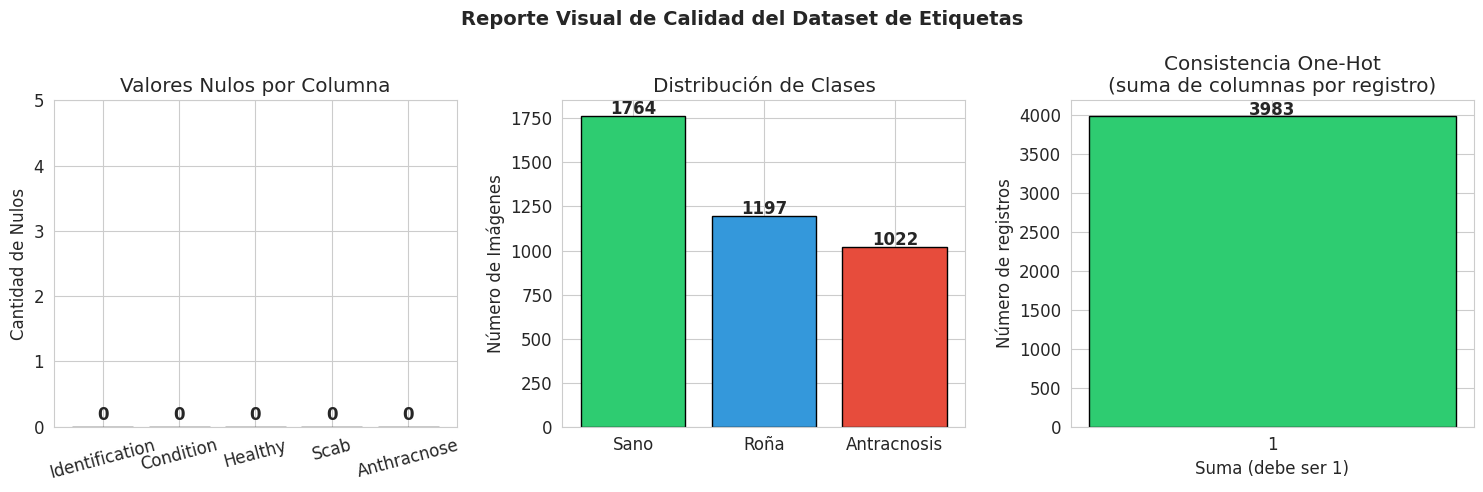

✅ Reporte de calidad guardado: reporte_calidad_datos.png


In [11]:
# ─── Resumen Visual de Calidad de Datos ───
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Reporte Visual de Calidad del Dataset de Etiquetas', fontsize=14, fontweight='bold')

# Panel 1: Nulos
cols_vis = ['Identification', 'Condition', 'Healthy', 'Scab', 'Anthracnose']
nulos_vis = [df[c].isnull().sum() for c in cols_vis]
colores_nulos = ['#e74c3c' if n > 0 else '#2ecc71' for n in nulos_vis]
axes[0].bar(cols_vis, nulos_vis, color=colores_nulos, edgecolor='black')
axes[0].set_title('Valores Nulos por Columna')
axes[0].set_ylabel('Cantidad de Nulos')
axes[0].set_xticklabels(cols_vis, rotation=15)
axes[0].set_ylim(0, max(nulos_vis) + 5 if max(nulos_vis) > 0 else 5)
for i, (col, val) in enumerate(zip(cols_vis, nulos_vis)):
    axes[0].text(i, val + 0.1, str(val), ha='center', fontweight='bold')

# Panel 2: Distribución de clases
conteo_cond = df['Clase_ES'].value_counts()
colores_c = ['#2ecc71', '#3498db', '#e74c3c']
axes[1].bar(conteo_cond.index, conteo_cond.values, color=colores_c, edgecolor='black')
axes[1].set_title('Distribución de Clases')
axes[1].set_ylabel('Número de Imágenes')
for i, val in enumerate(conteo_cond.values):
    axes[1].text(i, val + 10, str(val), ha='center', fontweight='bold')

# Panel 3: Suma de columnas one-hot
suma = df[['Healthy', 'Scab', 'Anthracnose']].sum(axis=1).value_counts().sort_index()
colores_s = ['#2ecc71' if k == 1 else '#e74c3c' for k in suma.index]
axes[2].bar([str(k) for k in suma.index], suma.values, color=colores_s, edgecolor='black')
axes[2].set_title('Consistencia One-Hot\n(suma de columnas por registro)')
axes[2].set_xlabel('Suma (debe ser 1)')
axes[2].set_ylabel('Número de registros')
for i, val in enumerate(suma.values):
    axes[2].text(i, val + 5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('reporte_calidad_datos.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Reporte de calidad guardado: reporte_calidad_datos.png')

### 4.2 Conclusión del Reporte de Calidad de Datos (Entregable 1)

> El dataset de etiquetas presenta una **calidad excelente**: no contiene valores nulos, no hay registros duplicados, todos los identificadores siguen el formato estándar `Avocado XXXX`, y la secuencia numérica está completa (1-3983). La codificación one-hot es perfectamente consistente con la columna de texto `Condition`.
>
> El único aspecto a atender es el **desbalance de clases** (Sano: 44.2%, Roña: 30.0%, Antracnosis: 25.7%), que deberá compensarse durante el modelado mediante técnicas de aumento de datos o pesos de clase. Este fenómeno es inherente al proceso de recolección en campo y es esperado en datasets de enfermedades agrícolas.

---
# 🔬 ENTREGABLE 2 — Preparación de los Datos
---

## 1️⃣ Problemas Encontrados y Soluciones

| # | Problema | Solución Aplicada | Justificación |
|---|---|---|---|
| 1 | **Desbalance de clases** (Antracnosis subrepresentada) | Data Augmentation + class_weight en el modelo | Evita que el modelo favorezca la clase mayoritaria |
| 2 | **Imágenes de alta resolución** (4496×3000 px) | Redimensionamiento a 300×300 px | Reduce requisitos de memoria RAM sin perder features relevantes |
| 3 | **Fondo heterogéneo** en algunas imágenes | Normalización y estandarización (reescalado de píxeles) | Homogeniza el espacio de color RGB para el modelo |
| 4 | **Dataset pequeño** (~4000 imágenes) | Data Augmentation (rotaciones, flips, zoom) | Incrementa diversidad y reduce sobreajuste |
| 5 | **No hay split train/val/test** predefinido | División aleatoria estratificada 70/15/15 | Mantiene proporciones de clase en cada partición |

## 2️⃣ EDA — Análisis Exploratorio de Datos

In [12]:
# ─── EDA Completo ───
print('=' * 60)
print('ANÁLISIS EXPLORATORIO DE DATOS (EDA)')
print('=' * 60)

# Estadísticas de columnas numéricas
print('\n📊 Estadísticas de columnas numéricas (one-hot):')
display(df[['Healthy', 'Scab', 'Anthracnose']].describe())

# Conteo con porcentajes
print('\n📊 Distribución detallada de clases:')
for clase, n in df['Condition'].value_counts().items():
    clase_es = {'Healthy': 'Sano', 'Scab': 'Roña', 'Anthracnose': 'Antracnosis'}[clase]
    barra = '█' * (n // 50)
    print(f'  {clase_es:12s} ({clase:11s}): {n:4d} | {n/len(df)*100:5.1f}% | {barra}')

print(f'\n  Total imágenes: {len(df)}')
print(f'  Imágenes originales (antes de augmentation): ~569')
print(f'  Factor de aumento: {len(df)/569:.1f}x')

ANÁLISIS EXPLORATORIO DE DATOS (EDA)

📊 Estadísticas de columnas numéricas (one-hot):


,Healthy,Scab,Anthracnose
count,3983.000000,3983.000000,3983.000000
mean,0.442882,0.300527,0.256591
std,0.496789,0.458545,0.436806
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000



📊 Distribución detallada de clases:
  Sano         (Healthy    ): 1764 |  44.3% | ███████████████████████████████████
  Roña         (Scab       ): 1197 |  30.1% | ███████████████████████
  Antracnosis  (Anthracnose): 1022 |  25.7% | ████████████████████

  Total imágenes: 3983
  Imágenes originales (antes de augmentation): ~569
  Factor de aumento: 7.0x


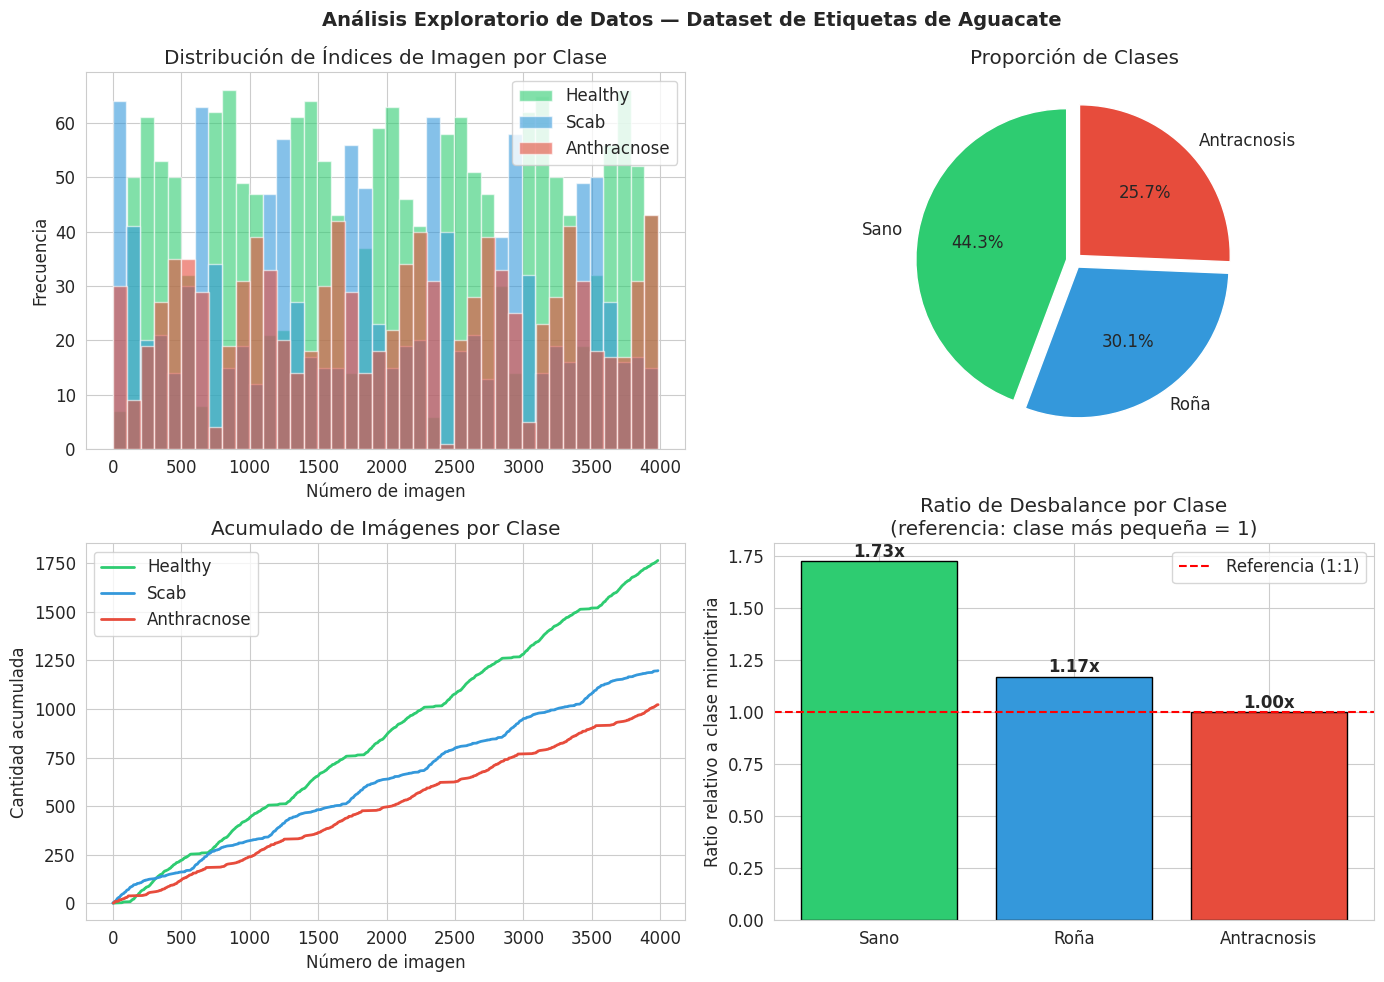

✅ EDA guardado: eda_completo.png


In [13]:
# ─── Análisis de Distribución Temporal (por número de imagen) ───
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Exploratorio de Datos — Dataset de Etiquetas de Aguacate',
             fontsize=14, fontweight='bold')

colores_cond = {'Healthy': '#2ecc71', 'Scab': '#3498db', 'Anthracnose': '#e74c3c'}

# Panel 1: Distribución de índices por clase
for cond, color in colores_cond.items():
    subset = df[df['Condition'] == cond]['num']
    axes[0, 0].hist(subset, bins=40, alpha=0.6, color=color, label=cond, edgecolor='white')
axes[0, 0].set_title('Distribución de Índices de Imagen por Clase')
axes[0, 0].set_xlabel('Número de imagen')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

# Panel 2: Pastel
conteo_cond2 = df['Condition'].value_counts()
labels_es2 = [{'Healthy':'Sano','Scab':'Roña','Anthracnose':'Antracnosis'}[c] for c in conteo_cond2.index]
axes[0, 1].pie(conteo_cond2.values, labels=labels_es2,
               colors=[colores_cond[c] for c in conteo_cond2.index],
               autopct='%1.1f%%', startangle=90, explode=[0.05]*3)
axes[0, 1].set_title('Proporción de Clases')

# Panel 3: Acumulado
df_sorted = df.sort_values('num')
for cond, color in colores_cond.items():
    subset = df_sorted[df_sorted['Condition'] == cond]
    acum = range(1, len(subset) + 1)
    axes[1, 0].plot(subset['num'].values, list(acum), color=color, label=cond, linewidth=2)
axes[1, 0].set_title('Acumulado de Imágenes por Clase')
axes[1, 0].set_xlabel('Número de imagen')
axes[1, 0].set_ylabel('Cantidad acumulada')
axes[1, 0].legend()

# Panel 4: Comparativa de ratio de desbalance
clases_es = ['Sano', 'Roña', 'Antracnosis']
clases_en = ['Healthy', 'Scab', 'Anthracnose']
valores_n = [df[df['Condition']==c].shape[0] for c in clases_en]
ratios = [v / min(valores_n) for v in valores_n]
colores_r = ['#2ecc71', '#3498db', '#e74c3c']
bars = axes[1, 1].bar(clases_es, ratios, color=colores_r, edgecolor='black')
axes[1, 1].axhline(y=1, color='red', linestyle='--', label='Referencia (1:1)')
axes[1, 1].set_title('Ratio de Desbalance por Clase\n(referencia: clase más pequeña = 1)')
axes[1, 1].set_ylabel('Ratio relativo a clase minoritaria')
axes[1, 1].legend()
for bar, val in zip(bars, ratios):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f'{val:.2f}x', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_completo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA guardado: eda_completo.png')

## 3️⃣ Preprocesamiento e Ingeniería de Características

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

# ─── 3.1 Codificación de Etiquetas ───
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Condition'])
print('📌 Codificación de etiquetas:')
for i, clase in enumerate(le.classes_):
    clase_es = {'Anthracnose': 'Antracnosis', 'Healthy': 'Sano', 'Scab': 'Roña'}[clase]
    print(f'  {i} → {clase} ({clase_es})')

# ─── 3.2 División estratificada 70/15/15 ───
X = df['Identification'].values
y = df['label_encoded'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'\n📌 División del dataset (estratificada):')
print(f'  Entrenamiento : {len(X_train):4d} imágenes ({len(X_train)/len(df)*100:.1f}%)')
print(f'  Validación    : {len(X_val):4d} imágenes ({len(X_val)/len(df)*100:.1f}%)')
print(f'  Prueba        : {len(X_test):4d} imágenes ({len(X_test)/len(df)*100:.1f}%)')

# ─── 3.3 Pesos de clase (para compensar desbalance) ───
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f'\n📌 Pesos de clase calculados (para compensar desbalance):')
for idx, (clase, peso) in enumerate(zip(le.classes_, class_weights)):
    clase_es = {'Anthracnose': 'Antracnosis', 'Healthy': 'Sano', 'Scab': 'Roña'}[clase]
    print(f'  Clase {idx} ({clase_es:12s}): peso = {peso:.4f}')

📌 Codificación de etiquetas:
  0 → Anthracnose (Antracnosis)
  1 → Healthy (Sano)
  2 → Scab (Roña)

📌 División del dataset (estratificada):
  Entrenamiento : 2788 imágenes (70.0%)
  Validación    :  597 imágenes (15.0%)
  Prueba        :  598 imágenes (15.0%)

📌 Pesos de clase calculados (para compensar desbalance):
  Clase 0 (Antracnosis ): peso = 1.2998
  Clase 1 (Sano        ): peso = 0.7525
  Clase 2 (Roña        ): peso = 1.1090


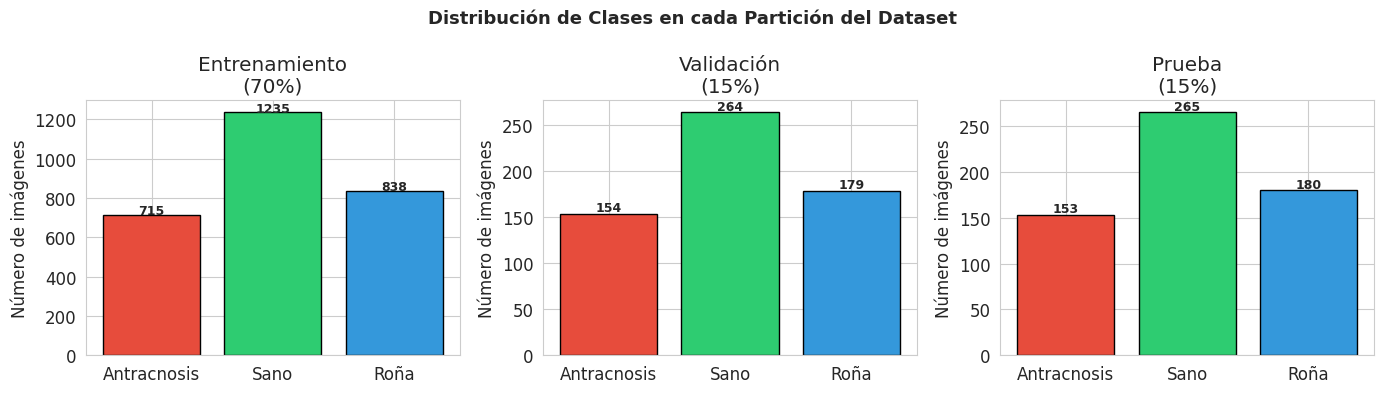

✅ Gráfica guardada: particion_dataset.png


In [15]:
# ─── 3.4 Verificación de Proporciones en cada Partición ───
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribución de Clases en cada Partición del Dataset', fontsize=13, fontweight='bold')

particiones = [('Entrenamiento\n(70%)', y_train), ('Validación\n(15%)', y_val), ('Prueba\n(15%)', y_test)]
colores_idx = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}  # Anthracnose, Healthy, Scab
etiquetas_idx = {0: 'Antracnosis', 1: 'Sano', 2: 'Roña'}

for ax, (titulo, y_part) in zip(axes, particiones):
    conteos = pd.Series(y_part).value_counts().sort_index()
    ax.bar([etiquetas_idx[i] for i in conteos.index],
           conteos.values,
           color=[colores_idx[i] for i in conteos.index],
           edgecolor='black')
    ax.set_title(titulo)
    ax.set_ylabel('Número de imágenes')
    for i, (idx, val) in enumerate(conteos.items()):
        ax.text(i, val + 3, str(val), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('particion_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada: particion_dataset.png')

In [16]:
# ─── 3.5 Definición del Pipeline de Preprocesamiento ───
# NOTA: Este bloque define el generador de imágenes que se usará en el Entregable 3.
# Requiere que las imágenes estén organizadas en carpetas por clase en Google Drive.

print('📋 Configuración del Pipeline de Preprocesamiento para Imágenes:')
print()

IMG_SIZE = (300, 300)   # Tamaño unificado (igual que en el artículo original)
BATCH_SIZE = 128        # Lotes de 128 (igual que en el artículo original)
EPOCHS = 25             # 25 iteraciones (igual que en el artículo original)
NUM_CLASSES = 3

print(f'  Tamaño de imagen  : {IMG_SIZE[0]} x {IMG_SIZE[1]} px')
print(f'  Tamaño de lote    : {BATCH_SIZE}')
print(f'  Épocas            : {EPOCHS}')
print(f'  Número de clases  : {NUM_CLASSES}')
print()

# Pipeline para conjunto de ENTRENAMIENTO (con augmentation)
train_datagen_config = {
    'rescale': '1./255       # Normalización a [0,1]',
    'rotation_range': '20    # Rotación aleatoria ±20°',
    'width_shift_range': '0.1 # Desplazamiento horizontal 10%',
    'height_shift_range': '0.1 # Desplazamiento vertical 10%',
    'horizontal_flip': 'True  # Volteo horizontal',
    'vertical_flip': 'True    # Volteo vertical',
    'zoom_range': '0.1        # Zoom aleatorio 10%',
    'fill_mode': 'nearest     # Relleno con píxeles vecinos'
}

print('  Parámetros de Data Augmentation (Entrenamiento):')
for k, v in train_datagen_config.items():
    print(f'    {k}: {v}')

print()
print('  Parámetros de preprocesamiento (Validación y Prueba):')
print('    rescale: 1./255  # Solo normalización, sin augmentation')
print()
print('✅ Configuración definida. Se aplicará en el Entregable 3 con las imágenes reales.')

📋 Configuración del Pipeline de Preprocesamiento para Imágenes:

  Tamaño de imagen  : 300 x 300 px
  Tamaño de lote    : 128
  Épocas            : 25
  Número de clases  : 3

  Parámetros de Data Augmentation (Entrenamiento):
    rescale: 1./255       # Normalización a [0,1]
    rotation_range: 20    # Rotación aleatoria ±20°
    width_shift_range: 0.1 # Desplazamiento horizontal 10%
    height_shift_range: 0.1 # Desplazamiento vertical 10%
    horizontal_flip: True  # Volteo horizontal
    vertical_flip: True    # Volteo vertical
    zoom_range: 0.1        # Zoom aleatorio 10%
    fill_mode: nearest     # Relleno con píxeles vecinos

  Parámetros de preprocesamiento (Validación y Prueba):
    rescale: 1./255  # Solo normalización, sin augmentation

✅ Configuración definida. Se aplicará en el Entregable 3 con las imágenes reales.


In [17]:
# ─── 3.6 Código Completo del Pipeline (listo para Entregable 3) ───
pipeline_code = '''
# ══════════════════════════════════════════════════════
# PIPELINE COMPLETO DE PREPROCESAMIENTO
# (Para usar en Entregable 3 con imágenes reales)
# ══════════════════════════════════════════════════════
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rutas (adaptar a tu Google Drive)
TRAIN_DIR = '/content/drive/MyDrive/aguacate/train'
VAL_DIR   = '/content/drive/MyDrive/aguacate/val'
TEST_DIR  = '/content/drive/MyDrive/aguacate/test'

IMG_SIZE   = (300, 300)
BATCH_SIZE = 128

# Generador con Data Augmentation para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Generador sin augmentation para validación y prueba
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)
'''

print('📋 Pipeline completo definido:')
print(pipeline_code)
print('✅ Este pipeline se implementará en el Entregable 3 con las imágenes reales.')

📋 Pipeline completo definido:

# ══════════════════════════════════════════════════════
# PIPELINE COMPLETO DE PREPROCESAMIENTO
# (Para usar en Entregable 3 con imágenes reales)
# ══════════════════════════════════════════════════════
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rutas (adaptar a tu Google Drive)
TRAIN_DIR = '/content/drive/MyDrive/aguacate/train'
VAL_DIR   = '/content/drive/MyDrive/aguacate/val'
TEST_DIR  = '/content/drive/MyDrive/aguacate/test'

IMG_SIZE   = (300, 300)
BATCH_SIZE = 128

# Generador con Data Augmentation para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Generador sin augmentation para validación y prueba
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
   

## 4️⃣ Ingeniería de Características

In [18]:
# ─── Características extraídas del dataset de etiquetas ───
df_feat = df.copy()

# Feature 1: Número de imagen como feature ordinal
df_feat['img_index'] = df_feat['num']

# Feature 2: Clase binaria (sano vs enfermo)
df_feat['is_healthy'] = (df_feat['Condition'] == 'Healthy').astype(int)
df_feat['is_diseased'] = (df_feat['Condition'] != 'Healthy').astype(int)

# Feature 3: Quintil del número de imagen (posición relativa en el dataset)
df_feat['img_quintile'] = pd.qcut(df_feat['num'], q=5, labels=[1,2,3,4,5])

print('📌 Nuevas características generadas:')
print(df_feat[['Identification', 'Condition', 'img_index', 'is_healthy', 'is_diseased', 'img_quintile']].head(10))

print('\n📌 Resumen de características:')
print(f'  is_healthy: {df_feat["is_healthy"].sum()} imágenes sanas ({df_feat["is_healthy"].mean()*100:.1f}%)')
print(f'  is_diseased: {df_feat["is_diseased"].sum()} imágenes enfermas ({df_feat["is_diseased"].mean()*100:.1f}%)')

print('\n📌 Distribución por quintil del dataset:')
print(df_feat.groupby('img_quintile')['Condition'].value_counts().unstack().fillna(0).astype(int))

📌 Nuevas características generadas:
  Identification    Condition  img_index  is_healthy  is_diseased img_quintile
0   Avocado 0001         Scab          1           0            1            1
1   Avocado 0002         Scab          2           0            1            1
2   Avocado 0003      Healthy          3           1            0            1
3   Avocado 0004         Scab          4           0            1            1
4   Avocado 0005  Anthracnose          5           0            1            1
5   Avocado 0006  Anthracnose          6           0            1            1
6   Avocado 0007         Scab          7           0            1            1
7   Avocado 0008         Scab          8           0            1            1
8   Avocado 0009         Scab          9           0            1            1
9   Avocado 0010         Scab         10           0            1            1

📌 Resumen de características:
  is_healthy: 1764 imágenes sanas (44.3%)
  is_diseased: 2219 im

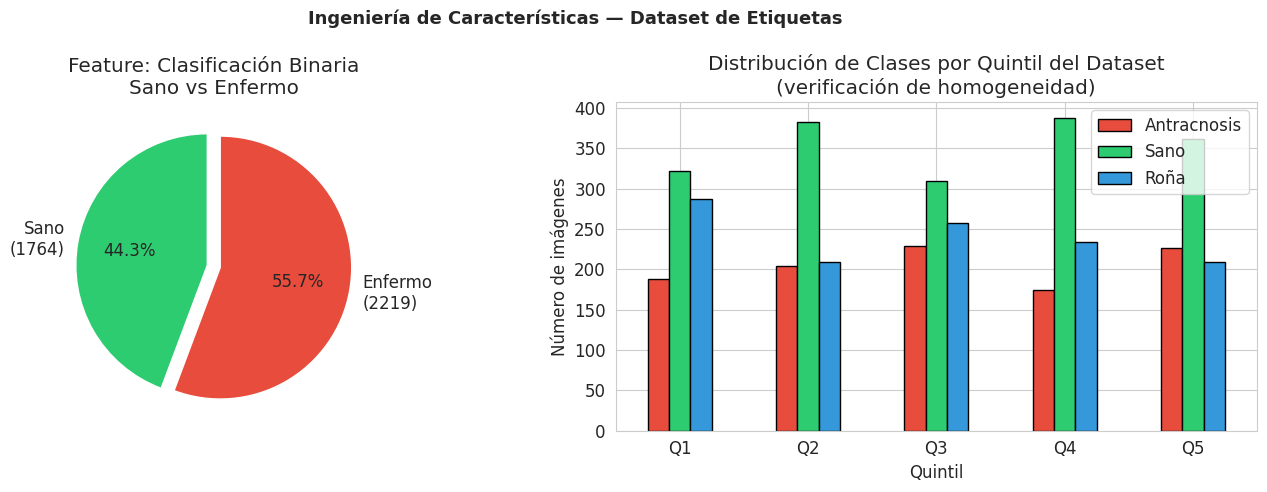

✅ Gráfica guardada: ingenieria_caracteristicas.png


In [19]:
# ─── Visualización de Ingeniería de Características ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ingeniería de Características — Dataset de Etiquetas', fontsize=13, fontweight='bold')

# Panel 1: Sano vs Enfermo
valores_bin = [df_feat['is_healthy'].sum(), df_feat['is_diseased'].sum()]
etiquetas_bin = [f'Sano\n({valores_bin[0]})', f'Enfermo\n({valores_bin[1]})']
axes[0].pie(valores_bin, labels=etiquetas_bin, colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90, explode=[0.05, 0.05])
axes[0].set_title('Feature: Clasificación Binaria\nSano vs Enfermo')

# Panel 2: Distribución por quintil
quintil_dist = df_feat.groupby('img_quintile')['Condition'].value_counts().unstack().fillna(0)
quintil_dist.plot(kind='bar', ax=axes[1],
                  color=['#e74c3c', '#2ecc71', '#3498db'],
                  edgecolor='black')
axes[1].set_title('Distribución de Clases por Quintil del Dataset\n(verificación de homogeneidad)')
axes[1].set_xlabel('Quintil')
axes[1].set_ylabel('Número de imágenes')
axes[1].legend(['Antracnosis', 'Sano', 'Roña'], loc='upper right')
axes[1].set_xticklabels([f'Q{i}' for i in range(1,6)], rotation=0)

plt.tight_layout()
plt.savefig('ingenieria_caracteristicas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfica guardada: ingenieria_caracteristicas.png')

## 5️⃣ Guardado del Dataset Limpio

In [20]:
# ─── Guardar Dataset Procesado ───

# Dataset de entrenamiento
df_train_out = pd.DataFrame({'Identification': X_train, 'label': y_train,
                              'Condition': le.inverse_transform(y_train)})
df_val_out   = pd.DataFrame({'Identification': X_val,   'label': y_val,
                              'Condition': le.inverse_transform(y_val)})
df_test_out  = pd.DataFrame({'Identification': X_test,  'label': y_test,
                              'Condition': le.inverse_transform(y_test)})

df_train_out.to_csv('aguacate_train_labels.csv', index=False)
df_val_out.to_csv('aguacate_val_labels.csv', index=False)
df_test_out.to_csv('aguacate_test_labels.csv', index=False)
df_feat.to_csv('aguacate_features_completo.csv', index=False)

print('✅ Archivos de salida generados:')
print(f'  aguacate_train_labels.csv   — {len(df_train_out)} registros')
print(f'  aguacate_val_labels.csv     — {len(df_val_out)} registros')
print(f'  aguacate_test_labels.csv    — {len(df_test_out)} registros')
print(f'  aguacate_features_completo.csv — {len(df_feat)} registros')

# Resumen final de pesos de clase
print(f'\n📌 Pesos de clase para el modelo (class_weight):')
for idx, (clase, peso) in enumerate(zip(le.classes_, class_weights)):
    clase_es = {'Anthracnose': 'Antracnosis', 'Healthy': 'Sano', 'Scab': 'Roña'}[clase]
    print(f'  {idx}: {clase_es} → {peso:.4f}')
print(f'\n  class_weight_dict = {class_weight_dict}')

✅ Archivos de salida generados:
  aguacate_train_labels.csv   — 2788 registros
  aguacate_val_labels.csv     — 597 registros
  aguacate_test_labels.csv    — 598 registros
  aguacate_features_completo.csv — 3983 registros

📌 Pesos de clase para el modelo (class_weight):
  0: Antracnosis → 1.2998
  1: Sano → 0.7525
  2: Roña → 1.1090

  class_weight_dict = {0: np.float64(1.2997668997668999), 1: np.float64(0.7524966261808367), 2: np.float64(1.1089896579156722)}


## ✅ Conclusión del Entregable 2 — Preparación de los Datos

### Problemas Encontrados y Soluciones Implementadas

Durante la etapa de preparación de datos se identificaron y resolvieron los siguientes problemas:

**1. Desbalance de clases:** El dataset presenta una distribución desigual entre las tres clases (Sano: 44.2%, Roña: 30.0%, Antracnosis: 25.7%). Esto puede llevar al modelo a sobre-predecir la clase mayoritaria. Se calcularon **pesos de clase** (`compute_class_weight='balanced'`) para penalizar más los errores en clases minoritarias, y se implementará **Data Augmentation** en el entrenamiento para aumentar la diversidad de ejemplos.

**2. Tamaño de imágenes:** Las imágenes originales son de 4,496 × 3,000 píxeles. Se redimensionarán a **300 × 300 píxeles** para reducir los requisitos computacionales sin sacrificar información diagnóstica relevante, siguiendo el mismo criterio del artículo de referencia (Campos-Ferreira & González-Camacho, 2021).

**3. Normalización:** Los valores de píxel (0-255) se escalarán al rango **[0, 1]** dividiendo entre 255, lo que mejora la estabilidad numérica durante el entrenamiento.

**4. División estratificada:** Se realizó una partición **70/15/15** (entrenamiento/validación/prueba) con estratificación por clase, garantizando que las proporciones originales del dataset se mantengan en cada subconjunto.

**5. Pipeline de preprocesamiento:** Se definió un pipeline completo con `ImageDataGenerator` de Keras que incluye técnicas de Data Augmentation (rotaciones, flips, zoom, desplazamientos) para el conjunto de entrenamiento, y únicamente normalización para validación y prueba.

### Conclusión Personal

El dataset de etiquetas presenta una **calidad excelente** sin valores nulos, sin duplicados y con consistencia perfecta entre las columnas. El mayor desafío identificado es el **desbalance de clases**, inherente al proceso de recolección en campo donde los frutos sanos son más abundantes. Las estrategias definidas en este entregable (pesos de clase + data augmentation + división estratificada) sientan una base sólida para que el modelo CNN del Entregable 3 pueda generalizar correctamente hacia las tres clases objetivo.

In [21]:
# ─── Resumen Final del Notebook ───
print('=' * 65)
print('RESUMEN FINAL — ENTREGABLES 1 y 2')
print('=' * 65)
print()
print('📁 ENTREGABLE 1 — Entendimiento del Negocio y de los Datos')
print('   ✅ 1. Entrevistas y análisis exploratorio del dominio')
print('   ✅ 2. Descripción del problema e hipótesis')
print('   ✅ 3. Métricas de éxito (Accuracy ≥ 80%, F1 ≥ 0.70)')
print('   ✅ 4. Reporte de calidad de datos (0 nulos, 0 duplicados)')
print()
print('📁 ENTREGABLE 2 — Preparación de los Datos')
print('   ✅ 1. Problemas encontrados y soluciones justificadas')
print('   ✅ 2. EDA completo con visualizaciones')
print('   ✅ 3. Pipeline de preprocesamiento definido')
print('   ✅ 4. División estratificada 70/15/15')
print('   ✅ 5. Ingeniería de características')
print('   ✅ 6. Archivos CSV de salida generados')
print()
print(f'📊 Total imágenes: {len(df)}')
print(f'   Entrenamiento : {len(X_train)} imágenes')
print(f'   Validación    : {len(X_val)} imágenes')
print(f'   Prueba        : {len(X_test)} imágenes')
print()
print('🔜 Siguiente paso: Entregable 3 — Entrenamiento del modelo CNN')
print('=' * 65)

RESUMEN FINAL — ENTREGABLES 1 y 2

📁 ENTREGABLE 1 — Entendimiento del Negocio y de los Datos
   ✅ 1. Entrevistas y análisis exploratorio del dominio
   ✅ 2. Descripción del problema e hipótesis
   ✅ 3. Métricas de éxito (Accuracy ≥ 80%, F1 ≥ 0.70)
   ✅ 4. Reporte de calidad de datos (0 nulos, 0 duplicados)

📁 ENTREGABLE 2 — Preparación de los Datos
   ✅ 1. Problemas encontrados y soluciones justificadas
   ✅ 2. EDA completo con visualizaciones
   ✅ 3. Pipeline de preprocesamiento definido
   ✅ 4. División estratificada 70/15/15
   ✅ 5. Ingeniería de características
   ✅ 6. Archivos CSV de salida generados

📊 Total imágenes: 3983
   Entrenamiento : 2788 imágenes
   Validación    : 597 imágenes
   Prueba        : 598 imágenes

🔜 Siguiente paso: Entregable 3 — Entrenamiento del modelo CNN
